This notebook will go over my experience with chapter 2's topic: Supervised learning

As a reminder, supervised learning is used whenever we want to predict a certain outcome from a given input, and we have examples of input/output pairs

There are two types of supervised learning problems: **classifcation** and **regression**<br>
In **classification**, the goal is to classify or categorize a sample into a *predefined* class<br>
In **regression**, the goal is to predict a continuous number (e.g., a floating point number)

As an interesting note, we may expect simple models to generalize better to new data since they may have less rules<br>
It's a balance between **overfitting** and **underfitting**

It is key to note that model complexity is intimately tied to the variation of inputs contained in your training data.

In [1]:
# load in the book's modules
# need this to import mglearn
import sys
sys.path.append('introduction_to_ml_with_python')
import mglearn

(26, 2)


Text(0, 0.5, 'Second feature')

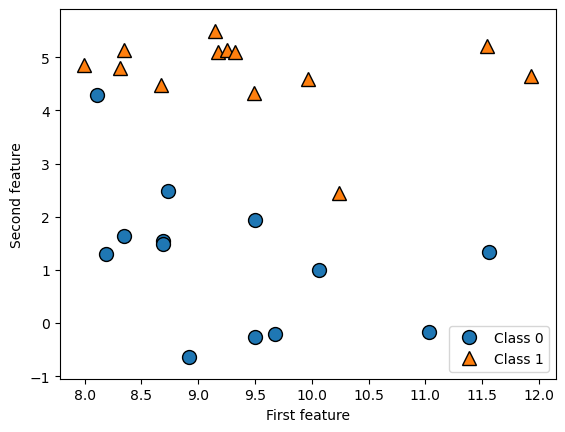

In [2]:
# create a dataset to get started
import matplotlib.pyplot as plt

x, y = mglearn.datasets.make_forge()
print(x.shape)
mglearn.discrete_scatter(x[:,0], x[:,1], y)
plt.legend(["Class 0", "Class 1"], loc = 4)
plt.xlabel("First feature")
plt.ylabel("Second feature")

Text(0, 0.5, 'Target')

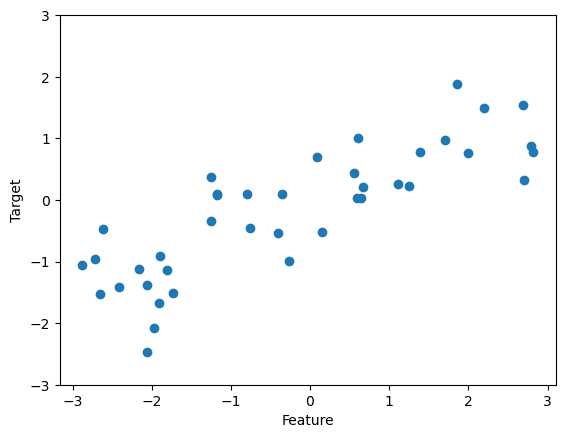

In [3]:
# just illustrating a very simple dataset
x, y = mglearn.datasets.make_wave(n_samples=40)
plt.plot(x, y, 'o')
plt.ylim(-3, 3)
plt.xlabel("Feature")
plt.ylabel("Target")

In [4]:
# now to apply a classification test
import numpy as np
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
print(cancer.keys())
print(cancer.data.shape)
print({n: v for n,v in zip(cancer.target_names, np.bincount(cancer.target))})

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
(569, 30)
{'malignant': 212, 'benign': 357}


In [5]:
# just loading some data that will be used for regression
from sklearn.datasets import load_boston
boston = load_boston()
print(boston.data.shape)

(506, 13)


/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function load_boston is deprecated; `load_boston` is deprecated in 1.0 and will be removed in 1.2.

    The Boston housing prices dataset has an ethical problem. You can refer to
    the documentation of this function for further details.

    The scikit-learn maintainers therefore strongly discourage the use of this
    dataset unless the purpose of the code is to study and educate about
    ethical issues in data science and machine learning.

    In this special case, you can fetch the dataset from the original
    source::

        import pandas as pd
        import numpy as np

        data_url = "http://lib.stat.cmu.edu/datasets/boston"
        raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
        data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
        target = raw_df.values[1::2, 2]

    Alternative datasets include the Califo

In [6]:
# there is an issue with the boston data set so I guess I will go cali dataset
from sklearn.datasets import fetch_california_housing, fetch_openml
housing = fetch_openml(name="house_prices", as_frame=True)

In [7]:
# but buston is aviable locally?
x, y = mglearn.datasets.load_extended_boston()
print(x.shape)

import pandas as pd
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
boston = raw_df.values[1::2, 2]

(506, 104)


/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function load_boston is deprecated; `load_boston` is deprecated in 1.0 and will be removed in 1.2.

    The Boston housing prices dataset has an ethical problem. You can refer to
    the documentation of this function for further details.

    The scikit-learn maintainers therefore strongly discourage the use of this
    dataset unless the purpose of the code is to study and educate about
    ethical issues in data science and machine learning.

    In this special case, you can fetch the dataset from the original
    source::

        import pandas as pd
        import numpy as np

        data_url = "http://lib.stat.cmu.edu/datasets/boston"
        raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
        data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
        target = raw_df.values[1::2, 2]

    Alternative datasets include the Califo

In [8]:
print(boston.data.shape)

(506,)


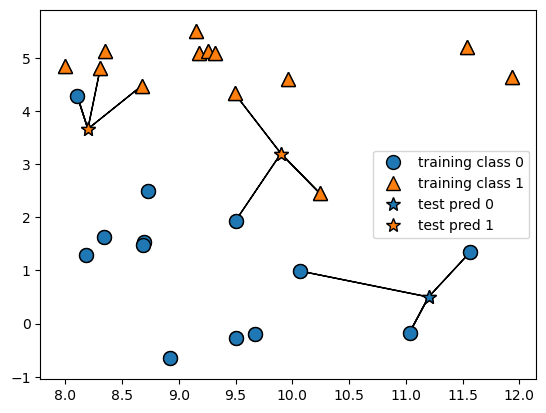

In [9]:
# knn is simple
mglearn.plots.plot_knn_classification(n_neighbors=1)
mglearn.plots.plot_knn_classification(n_neighbors=3)

In [10]:
from sklearn.model_selection import train_test_split
x, y = mglearn.datasets.make_forge()
xtrain, xtest, ytrain, ytest = train_test_split(x, y, random_state=0)

In [11]:
from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(xtrain, ytrain)
print(clf.predict(xtest))
print(clf.score(xtest, ytest))

[1 0 1 0 1 0 0]
0.8571428571428571


You will see that as we add more neighbors, the decision boundary tends to not follow the trained data as much (i.e., less neighbors, more following)

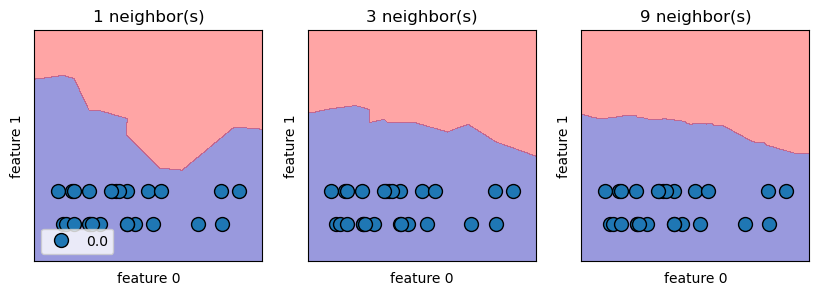

In [12]:
# plot
fig, axes = plt.subplots(1, 3, figsize = (10, 3))

for nneighbors, ax in zip([1, 3, 9], axes):
    clf = KNeighborsClassifier(n_neighbors=nneighbors).fit(x, y)
    mglearn.plots.plot_2d_separator(clf, x, fill=True, eps=0.5, ax=ax, alpha = 0.4)
    mglearn.discrete_scatter(x[:,0], y, ax = ax)
    ax.set_title(f"{nneighbors} neighbor(s)")
    ax.set_xlabel("feature 0")
    ax.set_ylabel("feature 1")
axes[0].legend(loc = 3)

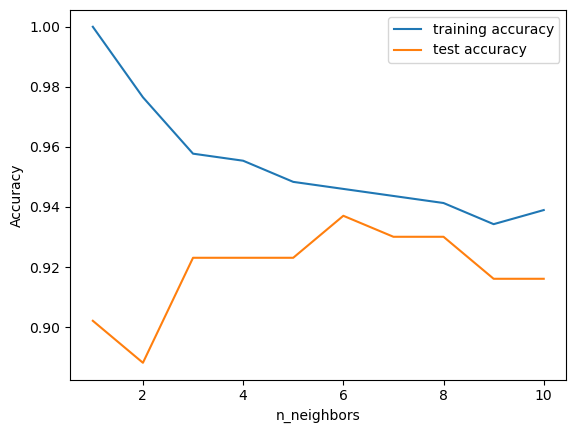

In [13]:
xtrain, xtest, ytrain, ytest = train_test_split(cancer.data, cancer.target, stratify=cancer.target, random_state=66)
train_accuracy = list()
test_accuracy  = list()
nei_settings   = range(1, 11)

for nnei in nei_settings:
    # build the model
    clf = KNeighborsClassifier(n_neighbors=nnei)
    clf.fit(xtrain, ytrain)
    train_accuracy.append(clf.score(xtrain, ytrain)) # record training set accuracy
    test_accuracy.append(clf.score(xtest, ytest))    # record generalization accuracy

plt.plot(nei_settings, train_accuracy, label = "training accuracy")
plt.plot(nei_settings, test_accuracy, label = "test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend() # performance tends to be best somewhere in the middle

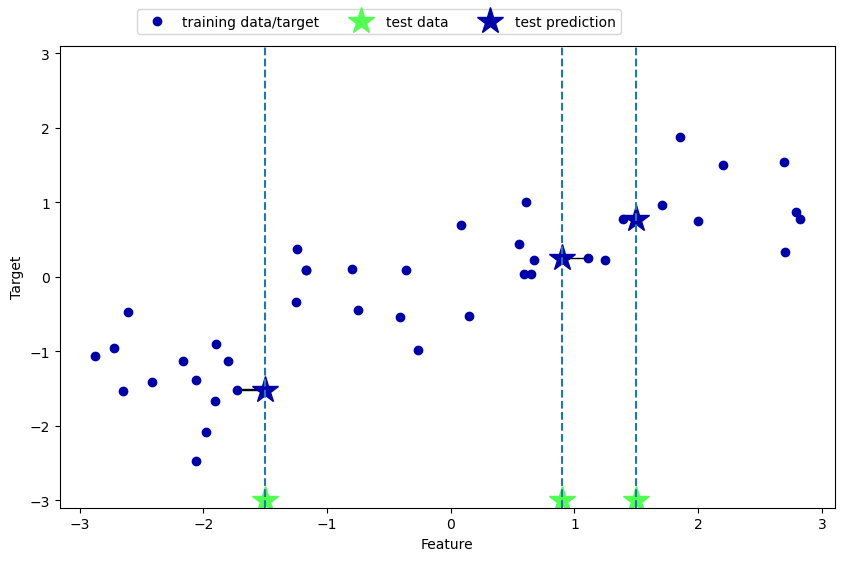

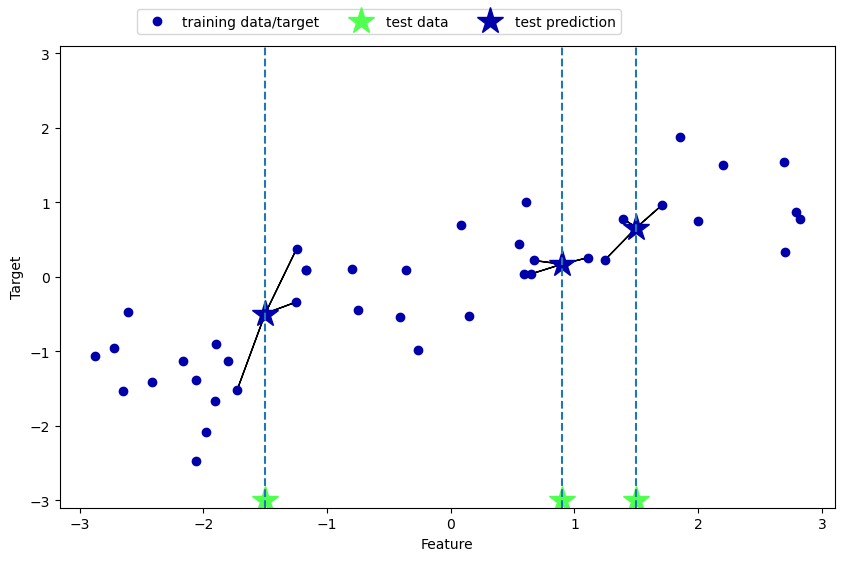

In [14]:
# doing a regression variant of the k-nearest neighbors algorithm
mglearn.plots.plot_knn_regression(n_neighbors=1)
mglearn.plots.plot_knn_regression(n_neighbors=3)

In [15]:
# doing it more manually
from sklearn.neighbors import KNeighborsRegressor
x, y = mglearn.datasets.make_wave(n_samples=40)

xtrain, xtest, ytrain, ytest = train_test_split(x, y, random_state=0)
reg = KNeighborsRegressor(n_neighbors=3)
reg.fit(xtrain, ytrain)
print(reg.predict(xtest))
print(reg.score(xtest, ytest))


[-0.05396539  0.35686046  1.13671923 -1.89415682 -1.13881398 -1.63113382
  0.35686046  0.91241374 -0.44680446 -1.13881398]
0.8344172446249605


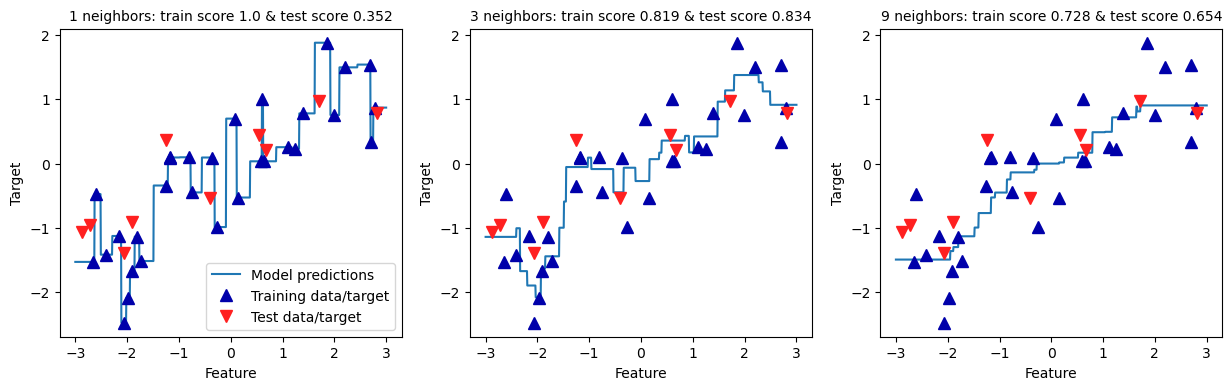

In [16]:
# to plot across multiple values
fig, axes = plt.subplots(1, 3, figsize = (15, 4))
line      = np.linspace(-3, 3, 1_000).reshape(-1, 1) # create 1,000 data points evenly spaced between -3 & 3
for nnei, ax in zip([1, 3, 9], axes):
    reg = KNeighborsRegressor(n_neighbors=nnei)
    reg.fit(xtrain, ytrain)
    ts = round(reg.score(xtrain, ytrain), 3)
    Ts = round(reg.score(xtest, ytest), 3)
    ax.plot(line, reg.predict(line))
    ax.plot(xtrain, ytrain, '^', c = mglearn.cm2(0), markersize = 8) 
    ax.plot(xtest, ytest, 'v', c = mglearn.cm2(1), markersize = 8) 
    ax.set_title(f"{nnei} neighbors: train score {ts} & test score {Ts}", fontsize = 10)
    ax.set_xlabel("Feature")
    ax.set_ylabel("Target")
axes[0].legend(["Model predictions", "Training data/target","Test data/target"], loc = "best")

w[0]: 0.393906  b: -0.031804


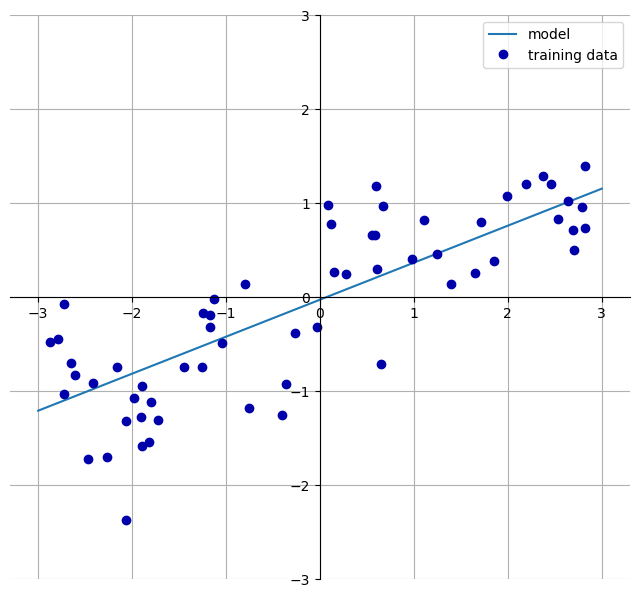

In [17]:
# here are the learned parameters based on a linear regression
mglearn.plots.plot_linear_regression_wave()

In [18]:
# now to go over a linear regression (aka ordinary least squares)
from sklearn.linear_model import LinearRegression
x, y = mglearn.datasets.make_wave(n_samples=60)
xtrain, xtest, ytrain, ytest = train_test_split(x, y, random_state=42)

lr = LinearRegression().fit(xtrain, ytrain) # remember, linear regression is parameters free

In [19]:
print(lr.coef_)
print(lr.intercept_)

[0.39390555]
-0.03180434302675973


In [20]:
print("Training", lr.score(xtrain, ytrain))
print("Testing", lr.score(xtest, ytest))

Training 0.6700890315075756
Testing 0.6593368596863701


# Ridge regression
In a ridge regression, the coefficients are chosen not only so that they predict well on the training data, but also to fit an additional constraint. It is also good to keep the magnitude of coefficients to be as small as possible (i.e., all entries of *w* should be close to zero). This means each feature should have as little effect on the outcome as possible while still predicting well

This is called **regularization**, which is used to restrict a model to avoid overfitting

In [21]:
from sklearn.linear_model import Ridge
ridge = Ridge() # didn't do this cause it requires the boston dataset...

# STOP AT PAGE 53

# Lasso
Lasso is a similar approach to a ridge regression, since it also restricts coefficients to be close to zero. However, it applies an L1 regularization algorithm which causes some coefficients to be exactly zero. This means some features are entirely ignored by the model. This can make the model easier to interpret & reveal the most important features

In [22]:
from sklearn.linear_model import Lasso
lasso = Lasso().fit(xtrain, ytrain)
print(lasso.score(xtrain, ytrain))
print(lasso.score(xtest, ytest))
print(np.sum(lasso.coef_ != 0)) # this is not good; again used a different data set since boston has been removed

0.2852883107043638
0.23759680165114305
1


In [23]:
# the above illustrates a case of underfitting. We can adjust the alpha (how strongly coefficients are pushed toward zero)
# if we do not want to change alpha, we can also tweak the maximum number of iterations to run
lasso001 = Lasso(alpha=0.01, max_iter=100_000).fit(xtrain, ytrain)
print(lasso001.score(xtrain, ytrain))
print(lasso001.score(xtest, ytest))
print(np.sum(lasso001.coef_ != 0))

0.6700505514354953
0.6575601699825229
1


In [24]:
# over fitting can occur if we lower the alpha & remove the effect of regularization
lasso0001 = Lasso(alpha=0.0001, max_iter=100_000).fit(xtrain, ytrain)
print(lasso0001.score(xtrain, ytrain))
print(lasso0001.score(xtest, ytest))
print(np.sum(lasso0001.coef_ != 0))

0.6700890276595685
0.6593193368604192
1


Text(0, 0.5, 'Coefficinet magnitude')

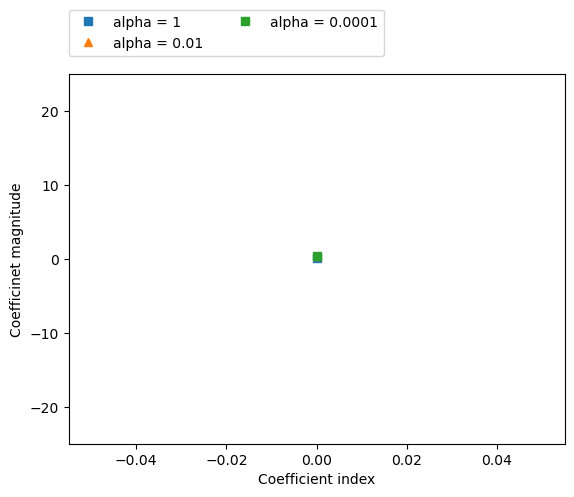

In [25]:
# plot the coefficients of different models

# I didn't use the right data set for this :(
plt.plot(lasso.coef_, 's', label = "alpha = 1")
plt.plot(lasso001.coef_, '^', label = "alpha = 0.01")
plt.plot(lasso0001.coef_, 's', label = "alpha = 0.0001")
plt.legend(ncol = 2, loc = (0, 1.05))
plt.ylim(-25, 25)
plt.xlabel("Coefficient index")
plt.ylabel("Coefficinet magnitude")

The two most common linear classification algorithms are **logistic regression** and **linear support vector machines**

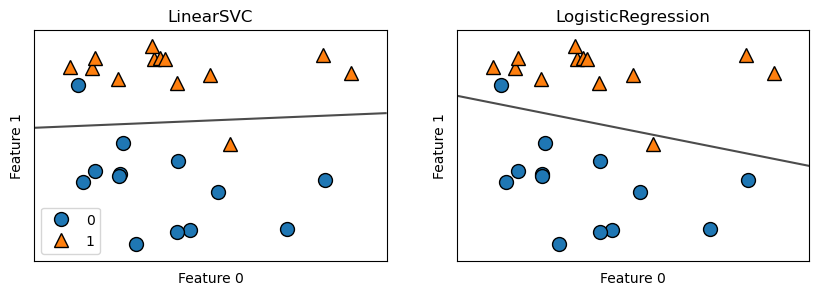

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

x, y = mglearn.datasets.make_forge()
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for model, ax in zip([LinearSVC(max_iter=10_000), LogisticRegression(max_iter=10_000)], axes):
    clf = model.fit(x, y)
    mglearn.plots.plot_2d_separator(clf, x, fill=False, eps=0.5, ax=ax, alpha=.7)
    mglearn.discrete_scatter(x[:, 0], x[:, 1], y, ax=ax)
    ax.set_title("{}".format(clf.__class__.__name__))
    ax.set_xlabel("Feature 0")
    ax.set_ylabel("Feature 1")
axes[0].legend()

From the figure above, we can see where the decision boundary is set. The trade-off parameter that determines the strength of the regularization is called **C**, and higher values of **C** correspond to *less* regularization. Meaning, when you use a high value of **C**, the models will try to fit the training set as best as possible, while low values allow the models to place more emphasis on fidning a coefficient vector that is close to zero.

Inheritetly, higher values of **C** stresses the importance that each individual data point can be classified correctly instead of just trying to adjust the majority of points

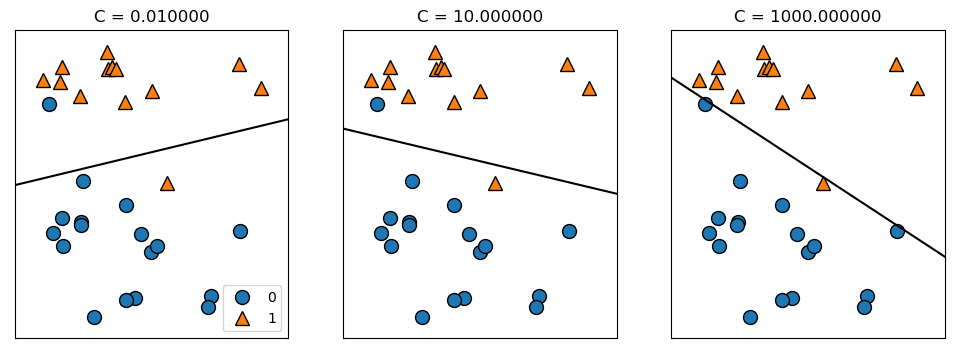

In [27]:
mglearn.plots.plot_linear_svc_regularization()

As *C** increases, the model tries harder to fit the two points misclassified at lower **C** values. For this data set, a linear model may not be the best approach

In [29]:
# looking at LinearLogistic
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
xtrain, xtest, ytrain, ytest = train_test_split(cancer.data, cancer.target,
                                                stratify=cancer.target, random_state=42)
logreg = LogisticRegression().fit(xtrain, ytrain)
print(logreg.score(xtrain, ytrain))
print(logreg.score(xtest, ytest))

0.9460093896713615
0.958041958041958


/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [30]:
# increase C in an already good model
logreg100 = LogisticRegression(C=100).fit(xtrain, ytrain)
print(logreg100.score(xtrain, ytrain))
print(logreg100.score(xtest, ytest))

0.9483568075117371
0.958041958041958


/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [33]:
# barely an improvement, but still an improvement?

# showing a worse model
logreg001 = LogisticRegression(C=0.01).fit(xtrain, ytrain)
print(logreg001.score(xtrain, ytrain))
print(logreg001.score(xtest, ytest))

0.9342723004694836
0.9300699300699301


/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


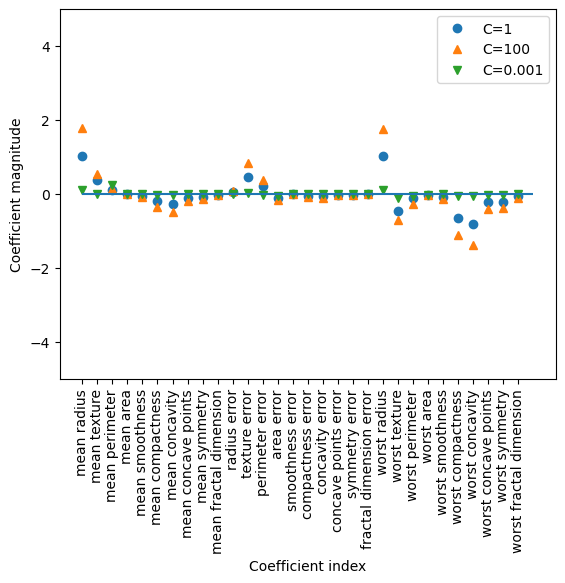

In [ ]:
plt.plot(logreg.coef_.T, 'o', label="C=1")
plt.plot(logreg100.coef_.T,
'^'
, label="C=100")
plt.plot(logreg001.coef_.T, 'v', label="C=0.001")
plt.xticks(range(cancer.data.shape[1]), cancer.feature_names, rotation=90)
plt.hlines(0, 0, cancer.data.shape[1])
plt.ylim(-5, 5)
plt.xlabel("Coefficient index")
plt.ylabel("Coefficient magnitude")
plt.legend()

# for C = 1 & 100, coefficients tend to lean negative

Training accuracy of l1 logreg with C=0.001: 0.94
Test accuracy of l1 logreg with C=0.001: 0.93
Training accuracy of l1 logreg with C=1.000: 0.95
Test accuracy of l1 logreg with C=1.000: 0.96
Training accuracy of l1 logreg with C=100.000: 0.95
Test accuracy of l1 logreg with C=100.000: 0.96


/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/l

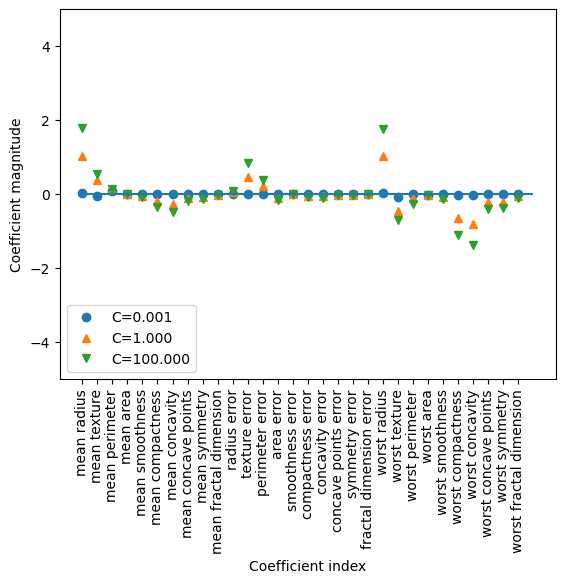

In [36]:
# to produce a more interpretable model, use L1 regularization, which will use only. a few of the feature

# igot an error trying l1 penalty, so I did l2 to get it to run
for C, marker in zip([0.001, 1, 100], ['o', '^', 'v']):
    lr_l1 = LogisticRegression(C=C, penalty="l2").fit(xtrain, ytrain)
    print("Training accuracy of l1 logreg with C={:.3f}: {:.2f}".format(C, lr_l1.score(xtrain, ytrain)))
    print("Test accuracy of l1 logreg with C={:.3f}: {:.2f}".format(C, lr_l1.score(xtest, ytest)))
    plt.plot(lr_l1.coef_.T, marker, label="C={:.3f}".format(C))
plt.xticks(range(cancer.data.shape[1]), cancer.feature_names, rotation=90)
plt.hlines(0, 0, cancer.data.shape[1])
plt.xlabel("Coefficient index")
plt.ylabel("Coefficient magnitude")
plt.ylim(-5, 5)
plt.legend(loc=3)

# Linear models for multiclass classification
A common technique to extend a binary classification algorithm ito a multiclass algorithm is the **one-vs.-rest** approach

In the one-vs.-rest approach, a binary model is learned for each class that tries to seperate that class from all the other classes, resulting in as many binary models as there are classes To make a prediction, all binary classifiers are run on a test point. The classifier that has the highest score on its single class "wins", and this class label is returned as the prediction

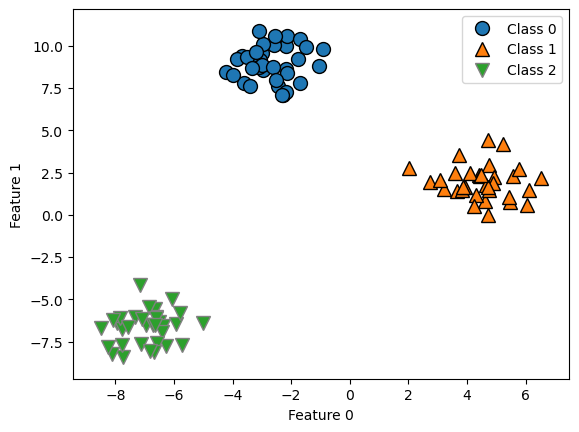

In [ ]:
# applying the one-vs.-rest approach

# just looking at the data
from sklearn.datasets import make_blobs
x, y = make_blobs(random_state=42)
mglearn.discrete_scatter(x[:, 0], x[:,1], y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.legend(["Class 0", "Class 1", "Class 2"])

In [ ]:
# train the model
linear_svm = LinearSVC().fit(x, y)
print(linear_svm.coef_.shape)
print(linear_svm.intercept_.shape) # this should resemble what we see above

(3, 2)
(3,)


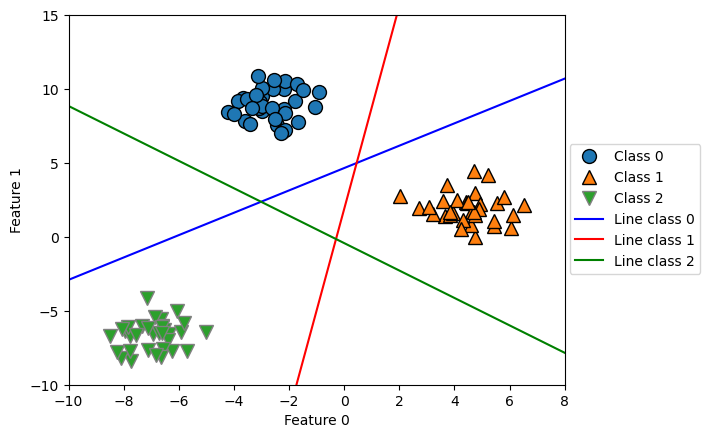

In [40]:
mglearn.discrete_scatter(x[:, 0], x[:, 1], y)
line = np.linspace(-15, 15)
for coef, intercept, color in zip(linear_svm.coef_, linear_svm.intercept_, ['b', 'r', 'g']):
    plt.plot(line, -(line * coef[0] + intercept) / coef[1], c=color)
plt.ylim(-10, 15)
plt.xlim(-10, 8)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.legend(['Class 0', 'Class 1', 'Class 2', 'Line class 0', 'Line class 1', 'Line class 2'], loc=(1.01, 0.3))

Text(0, 0.5, 'Feature 1')

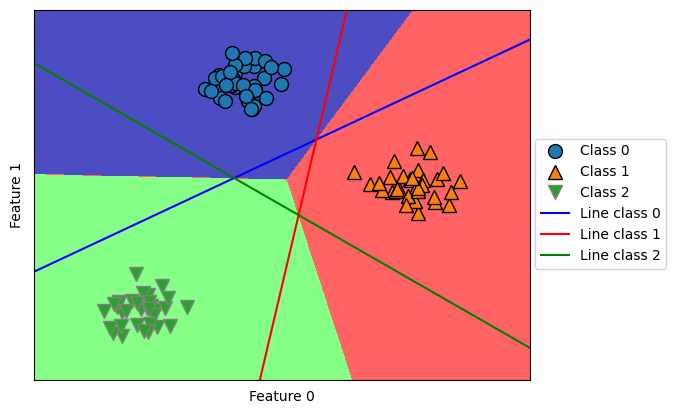

In [41]:
mglearn.plots.plot_2d_classification(linear_svm, x, fill=True, alpha=.7)
mglearn.discrete_scatter(x[:, 0], x[:, 1], y)
line = np.linspace(-15, 15)
for coef, intercept, color in zip(linear_svm.coef_, linear_svm.intercept_, ['b', 'r', 'g']):
    plt.plot(line, -(line * coef[0] + intercept) / coef[1], c=color)
plt.legend(['Class 0', 'Class 1', 'Class 2', 'Line class 0', 'Line class 1', 'Line class 2'], loc=(1.01, 0.3))
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

The main parameter of linear models is the regularization parameter, called *alpha* in the regression models and *C* in Linear SVC/Regression.

L2 vs L1, L1 is useful if you assume only a few features matters. Else, L2 is where you should start

# Naive Bayes Classifiers
Naive Bayes classifiers tend to be faster than linear models at training, but often provide generalization performance that is slightly worse. They are efficient because they learn parameters by looking at each feature individually & collect simple per-class stastisics from each feature

## Gaussian
Can be applied on continuous data

## Bernoulli
Can be applied on binary data

## Multinomial
Can be applied on count data

Bernoulli & Multinomial are mostly used in text data classification


In [44]:
# simulate data
x = np.array([[0, 1, 0, 1], [1, 0, 1, 1],
              [0, 0, 0, 1], [1, 0, 1, 0]])
y = np.array([0, 1, 0, 1])

# four data points with 4 features each
counts = {label : x[y == label].sum(axis = 0) for label in np.unique(y)}
print(counts)

{0: array([0, 1, 0, 2]), 1: array([2, 0, 2, 1])}


Multinomial takes into account the average value for each feature for each class, while Gaussian stores the average value and the standard deviation for each feature for each class

Multinomial & Bernoulli have a single parameter, *alpha*, which controls model complexity. The way *alpha* works is that the algorithm adds to the data *alpha* many virtual data points that have positive values for all the features. This results in a *smoothing* of the statistics. This doesn't really impact performance, more for accuracy

ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

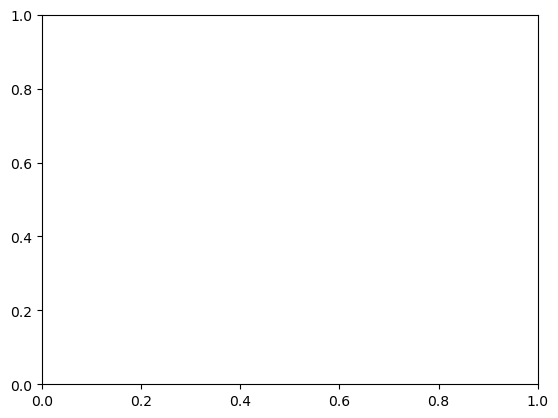

In [46]:
# Decision trees
mglearn.plots.plot_animal_tree()

Learning a decision tree means learning the sequence of if/else questions that get us to the true answer most quickly. Formally, these questions are known as *tests*

A lear of the decision tree that contains data points that all share the same target value is called *pure*. 

Building decision trees can easily lead to overfitting your data. You can prune the tree at different stages to avoid overfitting (pre or post pruning)

In [ ]:
# STOP on page 74